# Abnormal Distribution

![robot.png](https://live.staticflickr.com/65535/54430891765_38ef5cb61e_z.jpg)

*Image generated by ChatGPT.*

## Introduction

Noise has accompanied us for as long as we have been recording observations of any kind. Whether it is because we do not live in a world of classical philosophical abstractions, or perhaps the truth is much more mundane—frames of a camera, telescope lenses, text fragments, or audio recordings often include unwanted signals that—yes—co-create reality, but at the moment of making the observation, we would prefer to avoid them. In the context of this task, such redundant information superimposed on the base (true) information will be called noise.

Noise is considered and mathematically described—in the sciences, particularly in *information theory*. In computer graphics, noise (a *noise function*) will be called f:

$$f: X → X$$

where X is a specific domain of images. For images of size 28x28 in grayscale encoded in the range of real numbers [0, 1]:

$$X = [0,1]^{28 * 28}$$

It is a reasonable assumption that f differs significantly from the identity function, i.e., it substantially distorts the base image.

*Gaussian noise* is defined based on the **Gaussian distribution**, with probability density given by the formula:

$$f_{\mu, \sigma}(x) = \frac{1}{\sigma \sqrt{2π}}e^{\frac{-(x - \mu)^2}{2\sigma^2}}$$

The **Gaussian distribution** is parameterized by two constants: $\mu$ - *mean* and $\sigma$ - *standard deviation* or equivalently: $\mu$ - *mean* and $\sigma^2$ - *variance* (square of the standard deviation). Popular computing libraries contain implementations of *sampling* from this distribution. To noise an image with a parameterized distribution, we sample an array of size equal to the image size from the distribution, add the noise to the image (add *pixel-wise*), and then ensure that the pixel values remain in the range [0, 1] (the **clamp** function).

In [1]:
import torch

In [2]:
######################### DO NOT CHANGE THIS CELL ##########################

def add_normal_noise(image, mean=0, std=0.2):
    """Adds normal (Gaussian) noise to the image."""
    noise = torch.distributions.normal.Normal(mean, std)
    noise = noise.sample(image.size())
    noisy_image = image + noise
    return torch.clamp(noisy_image, 0.0, 1.0)

**Uniform distribution** has a simple intuition—we specify an interval $[a,b]$ and want the probability of drawing any two different numbers from the interval to be the same, and the probability of any number outside the interval to be zero. Formally, the probability density of the uniform distribution is given by the formula:

$$    
  f(x) =
  \begin{cases}
    \frac{1}{b-a}, & \text{for } a \leq x \leq b \\
    0
  \end{cases}
\
$$

When adding uniform noise to an image, we proceed analogously to Gaussian noise. We sample from the distribution, add it to the image, and any pixels outside the range $[0,1]$ are set to the appropriate boundary values.

In [3]:
######################### DO NOT CHANGE THIS CELL ##########################

def add_uniform_noise(image, low=-0.5, high=0.5):
    """Adds uniform noise to the image."""
    noise = torch.empty(image.size()).uniform_(low, high)
    noisy_image = image + noise
    return torch.clamp(noisy_image, 0.0, 1.0)

## Task

Imagine that you are an image processing specialist at a company dealing with image analysis and reconstruction. Your team is working on a system that can not only remove noise from images but also identify its type and parameters, which can provide valuable information about the source of the interference.

Your task is to design and train a single neural network architecture that will be able to simultaneously achieve three goals:

- **Image denoising** - restoring the original appearance of images corrupted by one of two types of noise: Gaussian or uniform;
- **Noise type classification** - determining whether the image was corrupted by Gaussian noise (label 0) or uniform noise (label 1);
- **Estimation of Gaussian noise parameters** - for images corrupted with Gaussian noise, the model should additionally estimate the parameters of that noise: the mean $\mu$ and standard deviation $\sigma$

**Note that each individual image has been corrupted by a randomly selected distribution with randomly selected (potentially different across the entire dataset) parameters.**

### Data
The data available to you in this task are:

- **Training dataset**, containing both original images and their noisy versions along with noise type labels
- **Validation dataset**, which will help you assess the quality of your model during training

We have prepared a dataloader for you. In the training set, each example consists of:

- Image before adding noise - key `['original']`
- Image after adding noise - key `['noised']`
- Noise type label - key `['label']`
- Noise parameters - key `['params']` (available only for the validation and test sets)

The image below illustrates an example process of generating noisy images for both noises parameterized with example arguments.

![noise_schema.png](https://live.staticflickr.com/65535/54429663172_1014ff20d7_z.jpg")

Your solution will ultimately be tested on the Competition Platform on a hidden test dataset, which is balanced in terms of noise types, and the images in it have the same characteristics as those provided to participants.


### Evaluation Criteria

As you might expect, in the evaluation we will assess four key aspects of your solution:

1. **Binary noise classification accuracy** (weight 25%) - how effectively the model recognizes the noise type:

$$    
  accuracyScore =
  \begin{cases}
    \frac{accuracy - 0.5}{0.45}, & \text{for } 0.5 < accuracy < 0.95 \\
    0.0, & \text{for } accuracy \leq 0.5 \\
    1.0, & \text{for } 0.95 \leq accuracy
  \end{cases}
\
$$

2. **Image reconstruction quality** (weight 25%) - measured by PSNR (Peak Signal-to-Noise Ratio):

$$    
  psnrScore =
  \begin{cases}
    \frac{PSNR - 10}{6}, & \text{for } 10 < PSNR < 16 \\
    0.0, & \text{for } PSNR \leq 10 \\
    1.0, & \text{for } 16 \leq PSNR
  \end{cases}
\
$$

where PSNR is defined as:

$$PSNR = 10 log_{10}\frac{MAX_{I}^{2}}{MSE},$$

where $MAX_{I}$ is the maximum possible pixel value in the given representation and in our case $MAX_{I} = 1$.


3. **Accuracy of estimating the mean parameter $\mu$ of Gaussian noise** (weight 25%) - measured by mean squared error (MSE) and calculated for test set elements with label 0 (Gaussian noise):

$$    
  meanMseScore =
  \begin{cases}
   1.0, & \text{for } MSE < 0.005 \\
   0.0, & \text {otherwise}
  \end{cases}
\
$$

4. **Accuracy of estimating the standard deviation parameter $\sigma$ of Gaussian noise** (weight 25%) - also measured by mean squared error (MSE) and calculated for test set elements with label 0 (Gaussian noise):

$$    
  stdMseScore =
  \begin{cases}
   1.0, & \text{for } MSE < 0.005 \\
   0.0, & \text {otherwise}
  \end{cases}
\
$$

**Final Scoring Formula**

The final score is the weighted sum of the above metrics according to the formula:
$$ finalScore = 25 \cdot accuracyScore + 25 \cdot psnrScore + 25 \cdot meanMseScore + 25 \cdot stdMseScore $$

For this task you can get from 0 to 100 points, where:

- Values close to 0 indicate a poor solution;
- Values close to 100 indicate an excellent solution that effectively classifies the noise type, reconstructs original images, and precisely estimates the parameters of Gaussian noise.

## Constraints

- You may only use the training set to train your model.
- Your solution will be tested on the Competition Platform without internet access and in a GPU environment.
- The evaluation of your final solution on the Competition Platform cannot take longer than 5 minutes on GPU.

## Submission Files

This notebook supplemented with your solution (see the `Model` class).

# Starter Code
In this section, we initialize the environment by importing the necessary libraries and functions. The prepared code will facilitate efficient data manipulation and building the appropriate solution.

In [4]:
######################### DO NOT CHANGE THIS CELL ##########################

FINAL_EVALUATION_MODE = False  # During checking, we will set this flag to True.

In [5]:
######################### DO NOT CHANGE THIS CELL ##########################

import os
import pickle
import random
from typing import Dict, List, Tuple
from collections.abc import Callable
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

assert torch.cuda.is_available(), "CUDA not available!"

print("Device:", DEVICE)

Device: cuda


In [6]:
######################### DO NOT CHANGE THIS CELL ##########################

seed = 42

os.environ["PYTHONHASHSEED"] = str(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [7]:
######################### DO NOT CHANGE THIS CELL ##########################
# Cell containing helper functions for visualizing results

def plot_samples(dataset: Dataset, num_images: int = 6, title: str = "") -> None:
    """
    Function to display examples of original and noisy images

    Args:
        dataset (Dataset): Dataset.
        num_images (int): Number of images to display.
    """
    fig, axs = plt.subplots(2, num_images, figsize=(2 * num_images, 4))
    fig.suptitle(title, fontsize=10)

    for i in range(num_images):
        sample = dataset[i]
        original_image = sample["original"]
        noised_image = sample["noised"]
        label = sample["label"]
        params = sample.get("params", None)

        column_title = f"Example {i+1}\nLabel: {label.item():.0f}"

        if params is not None:
            if label.item() == 0:
                column_title += f"\nμ: {params[0].item():.2f}\nσ: {params[1].item():.2f}"
            else:
                column_title += f"\nlow: {params[0].item():.2f}\nhigh: {params[1].item():.2f}"
        else:
            if label.item() == 0:
                column_title += "\nμ: N/A\nσ: N/A"
            else:
                column_title += "\nlow: N/A\nhigh: N/A"

        column_title += "\n\nOriginal"

        axs[0, i].set_title(column_title, fontsize=8, pad=5)
        axs[0, i].imshow(original_image.squeeze(), cmap="gray")
        axs[0, i].axis("off")

        axs[1, i].set_title("Noisy", fontsize=8, pad=5)
        axs[1, i].imshow(noised_image.squeeze(), cmap="gray")
        axs[1, i].axis("off")

    plt.tight_layout()
    plt.show()


def plot_results(model: nn.Module, examples: Dict, num_images: int = 6) -> None:
    """
    Function to display examples of noisy image and denoised by the model

    Args:
        model (nn.Module): Model for denoising images.
        examples (dict): Dictionary containing image examples.
        num_images (int): Number of images to display.
    """
    model.eval()
    noisy_images = examples["noised"][:num_images].to(DEVICE)
    clean_images = examples["original"][:num_images]
    label = examples["label"][:num_images]
    params = examples["params"][:num_images]
    mean_real = params[:, 0].view(-1, 1)
    std_real = params[:, 1].view(-1, 1)

    with torch.no_grad():
        output_images, predictions, mean_pred, std_pred = model(noisy_images.to(DEVICE))

    fig, axs = plt.subplots(3, num_images, figsize=(2 * num_images, 6))

    for i in range(num_images):
        column_title = (
            f"Example {i+1}\n"
            f"Label: {float(predictions[i].item() > 0.5):.0f}/{label[i].item():.0f}\n"
        )

        if label[i].item() == 0:
            column_title += (
                f"μ: {mean_pred[i].item():.2f}/{mean_real[i].item():.2f}\n"
                f"σ: {std_pred[i].item():.2f}/{std_real[i].item():.2f}\n"
            )
        else:
            column_title += "\n\n"

        column_title += "\nNoisy"

        axs[0, i].set_title(column_title, fontsize=8, pad=5)
        axs[0, i].imshow(noisy_images[i].cpu().squeeze(), cmap="gray")
        axs[0, i].axis("off")

        axs[1, i].set_title("Denoised", fontsize=8, pad=5)
        axs[1, i].imshow(output_images[i].cpu().squeeze(), cmap="gray")
        axs[1, i].axis("off")

        axs[2, i].set_title("Original", fontsize=8, pad=5)
        axs[2, i].imshow(clean_images[i].squeeze(), cmap="gray")
        axs[2, i].axis("off")

    fig.text(0.5, 0.01, "Format: Prediction/Label", ha='center', fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85, bottom=0.1)
    plt.show()


## Data Loading
Using the code below, the data will be loaded and appropriately prepared.

In [8]:
######################### DO NOT CHANGE THIS CELL ##########################
# Cell containing helper functions for data preparation.

class NoisedDataset(Dataset):
    """
    Dataset loaded from a pickle file.

    Args:
        file_path (str): Path to the pickle file containing the data.
        transform (callable, optional): Transformations applied to images and labels.
    """
    def __init__(self, pickle_file, transform=None):
        self.transform = transform

        with open(pickle_file, 'rb') as f:
            self.data = pickle.load(f)

        self.has_params = 'params' in self.data[0]

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx) -> Dict[str, torch.Tensor]:
        sample = self.data[idx]
        original_image = sample['original']
        noised_image = sample['noised']
        label = sample['label']

        if self.has_params:
            data = {'params': sample['params']}
        else:
            data = {}

        if self.transform:
            original_image = self.transform(original_image)
            noised_image = self.transform(noised_image)

        data.update({
            'original': original_image,
            'noised': noised_image,
            'label': label
        })

        return data


def setup_data(
        train_transform: Callable | None = None,
        val_transform: Callable | None = None,
        root: str = './'
    ) -> Tuple[Dataset, Dataset]:
    """
    Prepares training and validation datasets, downloading them if necessary.

    Args:
        train_transform (callable, optional): Augmentations for the training set.
        val_transform (callable, optional): Augmentations for the validation set.
        root (str, optional): Base directory for data files.

    Returns:
        tuple: Datasets (train_ds, val_ds).
    """
    if train_transform is None:
        train_transform = transforms.Compose([transforms.ToTensor()])
    if val_transform is None:
        val_transform = transforms.Compose([transforms.ToTensor()])

    train_file = root+'train.pkl'
    val_file = root+'val.pkl'

    if not os.path.exists(root):
        os.makedirs(root)

    train_ds = NoisedDataset(train_file, transform=train_transform)
    val_ds = NoisedDataset(val_file, transform=val_transform)

    return train_ds, val_ds

Number of images in training set: 30000 , number of images in validation set: 2000


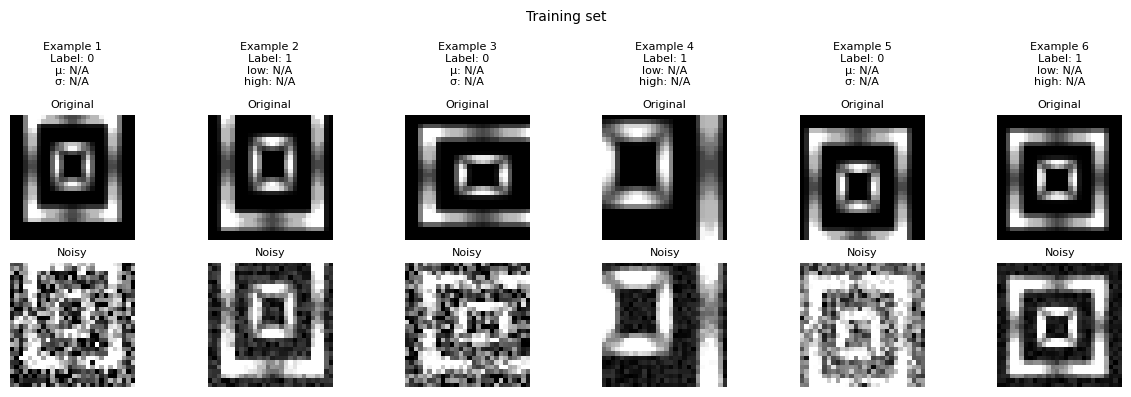

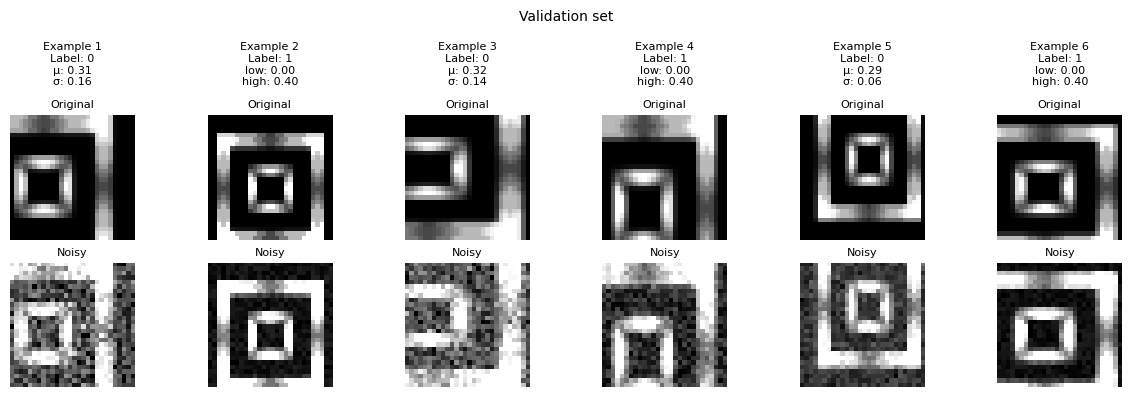

In [10]:
######################### DO NOT CHANGE THIS CELL ##########################

train_ds, val_ds = setup_data(root="./")

if not FINAL_EVALUATION_MODE:
    print("Number of images in training set:", len(train_ds), ", number of images in validation set:", len(val_ds))
    plot_samples(train_ds, num_images=6, title="Training set")
    plot_samples(val_ds, num_images=6, title="Validation set")

## Evaluation Criteria Code
Code similar to the one below will be used to evaluate the solution on the test set.

In [65]:
######################### DO NOT CHANGE THIS CELL ##########################
# Cell containing helper functions for calculating model metrics

def compute_psnr(input_image: torch.Tensor, target_image: torch.Tensor) -> torch.Tensor:
    """
    Function to calculate PSNR between two images.

    Args:
        input_image (torch.Tensor): First image.
        target_image (torch.Tensor): Second image.

    Returns:
        torch.Tensor: PSNR value.
    """
    mse = F.mse_loss(input_image, target_image)
    if mse == 0:
        return 100
    return 10 * torch.log10(1 / mse)

def model_eval(model: nn.Module, dataloader: DataLoader, device: str = DEVICE) -> Tuple[float, float, float, float]:
    """
    Function to evaluate the model on a dataset.

    Args:
        model (nn.Module): Model to evaluate.
        dataloader (DataLoader): DataLoader with evaluation data.
        device (str, optional): Device on which to perform evaluation.

    Returns:
        tuple: Tuple containing metric values (PSNR, accuracy, MSE for parameter 1, MSE for parameter 2).
    """
    model.eval()
    model.to(device)

    # Initialize variables to store results
    psnr = 0
    correct = 0
    mean_mse = 0
    std_mse = 0

    total_samples = 0
    total_label0_samples = 0

    with torch.no_grad():
        for data in dataloader:
            noised_images = data["noised"].to(device)
            original_images = data["original"].to(device)
            labels = data["label"].to(device)
            params = data["params"].to(device)
            batch_size = len(labels)

            mean_real = params[:, 0].view(-1, 1)
            std_real = params[:, 1].view(-1, 1)

            output_images, labels_pred, mean_pred, std_pred = model(noised_images)

            # Calculate classification accuracy
            correct += ((labels_pred >= 0.5).float().view(-1) == labels).sum().item()

            # Calculate PSNR
            psnr += compute_psnr(output_images, original_images) * batch_size

            # Calculate MSE for parameters when label is 0
            label0_mask = (labels == 0)
            num_label0 = label0_mask.sum().item()

            if num_label0 > 0:
                mean_mse += F.mse_loss(mean_pred[label0_mask], mean_real[label0_mask], reduction='sum')
                std_mse += F.mse_loss(std_pred[label0_mask], std_real[label0_mask], reduction='sum')

            total_samples += batch_size
            total_label0_samples += num_label0

    # Calculate average metric values
    psnr /= total_samples
    accuracy = correct / total_samples
    mean_mse /= total_label0_samples
    std_mse /= total_label0_samples

    return psnr.item(), accuracy, mean_mse.item(), std_mse.item()

In [12]:
######################### DO NOT CHANGE THIS CELL ##########################
# Cell containing helper functions for evaluating your solution

def calculate_score(
    psnr: float, accuracy: float, mean_mse: float, std_mse: float
) -> Tuple[float, float, float, float]:
    """
    Function to calculate points for the task based on model metrics.

    Args:
        psnr (float): PSNR value.
        accuracy (float): Classification accuracy.
        mean_mse (float): MSE for parameter 1.
        std_mse (float): MSE for parameter 2.

    Returns:
        tuple: Tuple containing points for the task (PSNR, accuracy, MSE for parameter 1, MSE for parameter 2).
    """

    def scale(x, lower=0.0, upper=1.0, max_points=1.0):
        scaled = min(max(x, lower), upper)
        return (scaled - lower) / (upper - lower) * max_points

    accuracy_score = scale(accuracy, lower=0.5, upper=0.95)
    psnr_score = scale(psnr, lower=10.0, upper=16.0)

    mean_score = 0.0
    if mean_mse < 0.005:
        mean_score = 1.0

    std_score = 0.0
    if std_mse < 0.005:
        std_score = 1.0

    return psnr_score, accuracy_score, mean_score, std_score


def grade_solution(model: nn.Module, dataloader: DataLoader) -> float:
    """
    Function to evaluate the model on the validation set.

    Args:
        model (nn.Module): Model to evaluate.
        dataloader (DataLoader): DataLoader with evaluation data.

    Returns:
        float: Number of points for the task.
    """
    psnr, accuracy, mean_mse, std_mse = model_eval(model, dataloader)
    psnr_score, accuracy_score, mean_score, std_score = calculate_score(
        psnr, accuracy, mean_mse, std_mse
    )
    score = round(
        psnr_score * 25 + accuracy_score * 25 + mean_score * 25 + std_score * 25
    )

    # Round to integer, range [0, 100]
    score = round(score)

    print(
        f"Metrics on validation set\n"
        f"psnr: {psnr:.2f}, accuracy: {accuracy:.2f}, mean_mse: {mean_mse:.6f}, std_mse: {std_mse:.6f}\n"
    )
    print(
        f"Partial points for the task\n"
        f"psnr: {(psnr_score * 25):.2f}, accuracy: {(accuracy_score * 25):.2f}, mean_mse: {(mean_score * 25):.2f}, std_mse: {(std_score * 25):.2f}\n"
    )
    print(f"Estimated points for the task: {score}")
    return score


# Your Solution
In this section, you should place your solution. Make changes only here!

In [16]:
# definitions of augmentations for training and validation sets. Default None means no augmentation
train_transform = None
val_transform = None

# batch size
BATCH_SIZE: int = 32

train_ds, val_ds = setup_data(train_transform, val_transform, root="./")
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

In [67]:
# here create and train your model

class DoubleConv(nn.Module):
    def __init__(self, in_f, out_f, down=True):
        super().__init__()
        self.down = down
        self.model = nn.Sequential(
            nn.Conv2d(in_f, out_f, 3, 1, 1),
            nn.BatchNorm2d(out_f),
            nn.ReLU(),
            nn.Conv2d(out_f,out_f, 3, 1, 1),
            nn.BatchNorm2d(out_f),
            nn.ReLU()
        )
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        if self.down:
            return self.pool(self.model(x))
        return self.model(x)

class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = DoubleConv(1,16)
        self.down2 = DoubleConv(16,64)
        self.up2 = DoubleConv(64, 16, False)
        self.up1 = DoubleConv(16, 1, False)

        self.noise_classifier = nn.Sequential(
            DoubleConv(1,16),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        """
        Transformation performed by the model.

        Args:
            x (torch.Tensor): Input image [B, 1, H, W].

        Returns:
            Result returned as a tuple:
            torch.Tensor: Output image [B, 1, H, W].
            torch.Tensor: Classification predictions [B, 1].
            torch.Tensor: Parameter 1 [B, 1].
            torch.Tensor: Parameter 2 [B, 1].
        """

        x_d1 = self.down1(x)
        x_d2 = self.down2(x_d1)
        x_d2 = F.interpolate(x_d2, scale_factor=2, mode='bilinear')
        x_d1 = self.up2(x_d2) + x_d1
        x_d1 = F.interpolate(x_d1, scale_factor=2, mode='bilinear')
        neg_noise = self.up1(x_d1)
        x = neg_noise + x
        noise_class = self.noise_classifier(neg_noise)
        mean = -torch.mean(neg_noise, dim=(1,2,3))
        std = torch.std(neg_noise, dim=(1,2,3))

        return (
            x,
            noise_class,
            mean,
            std
        )


def train_model() -> Model:
    """Create and train the model"""
    model = Model().to(DEVICE)

    criterion = nn.MSELoss()
    criterion_classification = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    num_epochs = 10

    for epoch in range(num_epochs):
        model.train()

        train_loss = 0.0

        for x in train_loader:
            noised = x['noised'].to(DEVICE)
            original = x['original'].to(DEVICE)
            labels = x['label'].to(DEVICE)

            optimizer.zero_grad()

            denoised, noise_class, _, _ = model(noised)
            loss = criterion(denoised, original)
            loss_clasification = criterion_classification(noise_class.squeeze(1), labels)
            loss += 0.2*loss_clasification

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            train_loss += loss.item() * noised.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()

        val_loss = 0.0

        with torch.no_grad():
            for x in val_loader:
                noised = x['noised'].to(DEVICE)
                original = x['original'].to(DEVICE)
                labels = x['label'].to(DEVICE)

                denoised, noise_class, _, _ = model(noised)

                loss = criterion(denoised, original)
                loss_clasification = criterion_classification(noise_class.squeeze(1), labels)
                loss += 0.2*loss_clasification

                val_loss += loss.item() * noised.size(0)

        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)

        print(
            f"Epoch {epoch+1:03d} | "
            f"train={train_loss:.6f} | "
            f"val={val_loss:.6f}"
        )

    return model


your_model = train_model()

Epoch 001 | train=0.148962 | val=0.308577
Epoch 002 | train=0.118484 | val=0.137268
Epoch 003 | train=0.111401 | val=0.310616
Epoch 004 | train=0.106017 | val=0.107378
Epoch 005 | train=0.102670 | val=0.547495
Epoch 006 | train=0.099985 | val=0.192128
Epoch 007 | train=0.098902 | val=0.268699
Epoch 008 | train=0.095321 | val=0.092011
Epoch 009 | train=0.095340 | val=0.105311
Epoch 010 | train=0.094630 | val=0.100547


In [62]:
from torchinfo import summary
summary(Model(), [2, 1,28,28])

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [2, 1, 28, 28]            --
├─DoubleConv: 1-1                        [2, 16, 14, 14]           --
│    └─Sequential: 2-1                   [2, 16, 28, 28]           --
│    │    └─Conv2d: 3-1                  [2, 16, 28, 28]           160
│    │    └─BatchNorm2d: 3-2             [2, 16, 28, 28]           32
│    │    └─ReLU: 3-3                    [2, 16, 28, 28]           --
│    │    └─Conv2d: 3-4                  [2, 16, 28, 28]           2,320
│    │    └─BatchNorm2d: 3-5             [2, 16, 28, 28]           32
│    │    └─ReLU: 3-6                    [2, 16, 28, 28]           --
│    └─MaxPool2d: 2-2                    [2, 16, 14, 14]           --
├─DoubleConv: 1-2                        [2, 64, 7, 7]             --
│    └─Sequential: 2-3                   [2, 64, 14, 14]           --
│    │    └─Conv2d: 3-7                  [2, 64, 14, 14]           9,280
│    │  

# Evaluation
Running the cell below will allow you to check how many points your solution would score on the validation data. Before submitting, make sure that the entire notebook runs from start to finish without errors and without user intervention after selecting the "Run All" option.

C:\Users\raian\AppData\Local\Temp\ipykernel_19372\2069750497.py:68: UserWarning: Using a target size (torch.Size([16, 1])) that is different to the input size (torch.Size([16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  mean_mse += F.mse_loss(mean_pred[label0_mask], mean_real[label0_mask], reduction='sum')
C:\Users\raian\AppData\Local\Temp\ipykernel_19372\2069750497.py:69: UserWarning: Using a target size (torch.Size([16, 1])) that is different to the input size (torch.Size([16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  std_mse += F.mse_loss(std_pred[label0_mask], std_real[label0_mask], reduction='sum')
C:\Users\raian\AppData\Local\Temp\ipykernel_19372\2069750497.py:68: UserWarning: Using a target size (torch.Size([8, 1])) that is different to the input size (torch.Size([8])). This will likely lead to incorrect results due to broadcasting. Please ensure they

Metrics on validation set
psnr: 10.50, accuracy: 0.98, mean_mse: 1.283425, std_mse: 0.496818

Partial points for the task
psnr: 2.10, accuracy: 25.00, mean_mse: 0.00, std_mse: 0.00

Estimated points for the task: 27


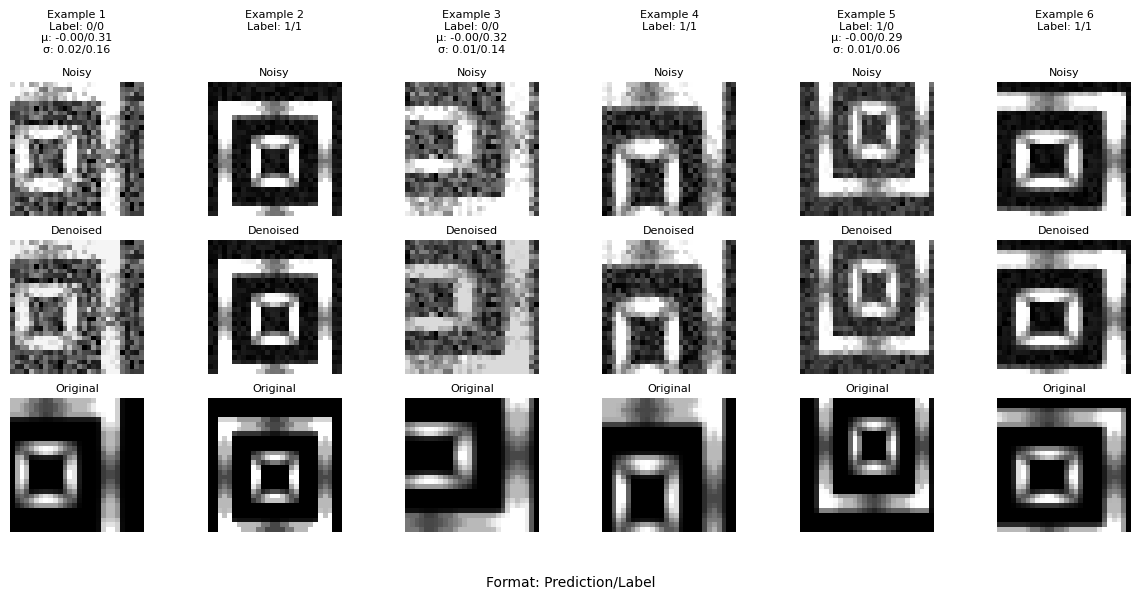

In [68]:
######################### DO NOT CHANGE THIS CELL ##########################

val_dataloader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

if not FINAL_EVALUATION_MODE:
    grade_solution(your_model, val_dataloader)
    examples = next(iter(val_dataloader))
    plot_results(your_model, examples, num_images=6)

During checking, the model will be saved as `your_model.pkl` and evaluated on the test set.

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

if FINAL_EVALUATION_MODE:
    import cloudpickle

    # If the model has parameters, set it to evaluation mode and move to CPU
    if list(your_model.parameters()):
        your_model.eval()
        your_model.cpu()

    OUTPUT_PATH = "file_output"
    FUNCTION_FILENAME = "your_model.pkl"
    FUNCTION_OUTPUT_PATH = os.path.join(OUTPUT_PATH, FUNCTION_FILENAME)

    if not os.path.exists(OUTPUT_PATH):
        os.makedirs(OUTPUT_PATH)

    with open(FUNCTION_OUTPUT_PATH, "wb") as f:
        cloudpickle.dump(your_model, f)